# Analyze Leakage and Essential Usage Rates by Context String Length (16-Context File)

This notebook loads the evaluation results from the 16-context experiment and analyzes how the string length of the context entries correlates with the leakage rate (of sensitive data) and the usage rate (of essential data).
Each data point represents a specific context item (either sensitive or essential), relating its text length to whether it was used/leaked.

In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Load data
file_path = pathlib.Path('../data/trajectory/azure-gpt-4o-20241120/naive/ess4_sen4/evaluated_trajectory.json')

if not file_path.exists():
    print(f"File not found: {file_path}")
else:
    with open(file_path, 'r') as f:
        data = json.load(f)
    print(f"Loaded {len(data)} entries")

# Extract lengths and usage
# We will create two dataframes: one for sensitive items, one for essential items
sensitive_items = []
essential_items = []

for entry in data:
    # Sensitive Data
    sen_data = entry.get('sensitive_data', [])
    sen_usage = entry.get('sensitive_usage', [])
    
    # Essential Data
    ess_data = entry.get('essential_data', [])
    ess_usage = entry.get('essential_usage', [])
    
    # Process Sensitive
    for content_item, is_leaked in zip(sen_data, sen_usage):
        if is_leaked is None:
            continue
        # The content_item is a dict with 'Content' key
        content = content_item.get('Content', '')
        sensitive_items.append({
            'length': len(content),
            'used': is_leaked,
            'log_length': np.log1p(len(content))
        })
        
    # Process Essential
    for content_item, is_used in zip(ess_data, ess_usage):
        if is_used is None:
            continue
        content = content_item.get('Content', '')
        essential_items.append({
            'length': len(content),
            'used': is_used,
            'log_length': np.log1p(len(content))
        })

df_sen = pd.DataFrame(sensitive_items)
df_ess = pd.DataFrame(essential_items)

print(f"Sensitive Items: {len(df_sen)}")
print(f"Essential Items: {len(df_ess)}")
df_sen.head()

Loaded 122 entries
Sensitive Items: 401
Essential Items: 448


,length,used,log_length
0,156,False,5.056246
1,166,False,5.117994
2,151,False,5.023881
3,132,False,4.890349
4,133,False,4.897840


In [3]:
num_bins=10
# Binning Sensitive
df_sen['length_bin'] = pd.qcut(df_sen['length'], q=num_bins, duplicates='drop')
sen_imbalance = df_sen.groupby('length_bin', observed=False)['used'].agg(['mean', 'count']).reset_index()
sen_imbalance.rename(columns={'mean': 'leakage_rate', 'count': 'entry_count'}, inplace=True)
sen_imbalance['mid_point'] = sen_imbalance['length_bin'].apply(lambda x: x.mid).astype(float)

# Binning Essential
df_ess['length_bin'] = pd.qcut(df_ess['length'], q=num_bins, duplicates='drop')
ess_imbalance = df_ess.groupby('length_bin', observed=False)['used'].agg(['mean', 'count']).reset_index()
ess_imbalance.rename(columns={'mean': 'usage_rate', 'count': 'entry_count'}, inplace=True)
ess_imbalance['mid_point'] = ess_imbalance['length_bin'].apply(lambda x: x.mid).astype(float)

# display(sen_imbalance)
# display(ess_imbalance)

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='mid_point', ylabel='leakage_rate'>

<Axes: xlabel='mid_point', ylabel='leakage_rate'>

Text(0.5, 1.0, 'Rates vs. Context String Length (Binned by Quantile)')

Text(0.5, 0, 'Average Context Length (Characters)')

Text(0, 0.5, 'Rate')

(0.0, 1.0)

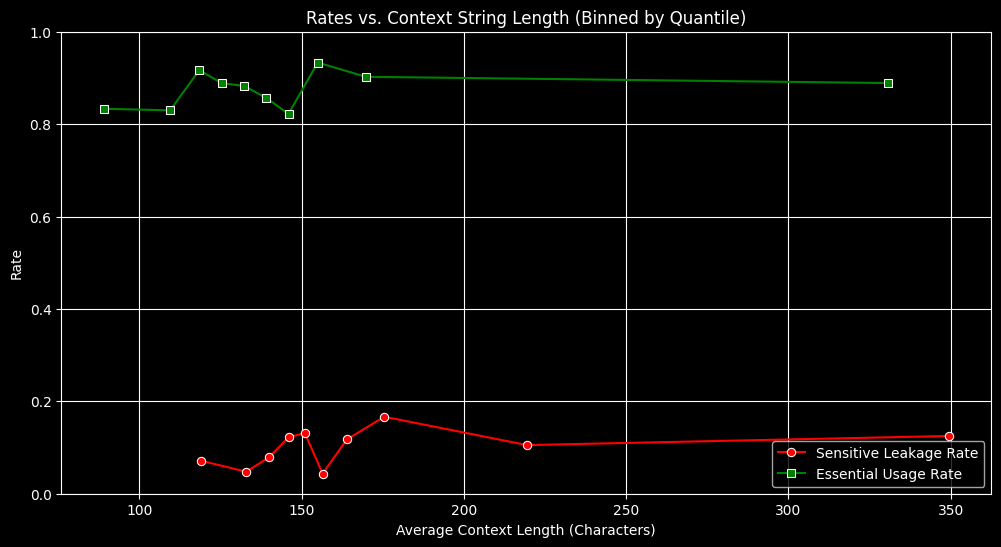

/tmp/ipykernel_3961265/1618251155.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='used', y='length', data=df_sen, ax=axes[0], palette='Reds')


<Axes: xlabel='used', ylabel='length'>

Text(0.5, 1.0, 'Sensitive: Length Distribution by Leakage Status')

/tmp/ipykernel_3961265/1618251155.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Leaked', 'Leaked'])


[Text(0, 0, 'Not Leaked'), Text(1, 0, 'Leaked')]

/tmp/ipykernel_3961265/1618251155.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='used', y='length', data=df_ess, ax=axes[1], palette='Greens')


<Axes: xlabel='used', ylabel='length'>

Text(0.5, 1.0, 'Essential: Length Distribution by Usage Status')

/tmp/ipykernel_3961265/1618251155.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Used', 'Used'])


[Text(0, 0, 'Not Used'), Text(1, 0, 'Used')]

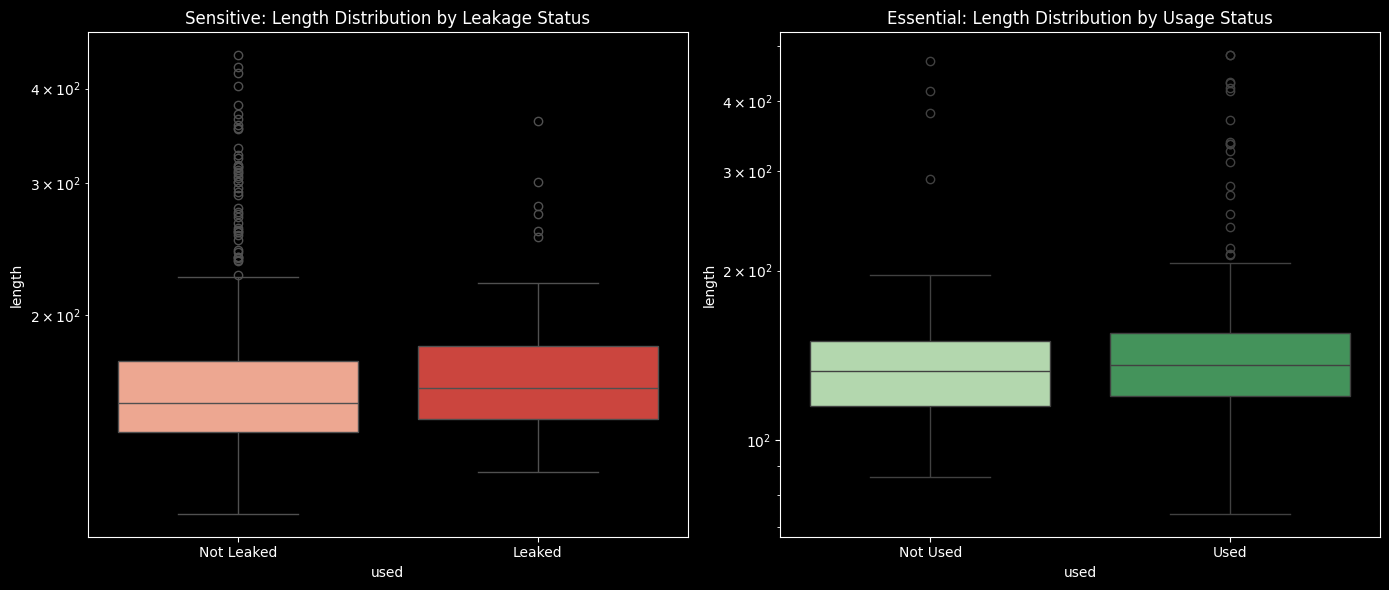

In [6]:
# Plotting

plt.figure(figsize=(12, 6))

# Plot Sensitive Leakage Rate
sns.lineplot(data=sen_imbalance, x='mid_point', y='leakage_rate', marker='o', label='Sensitive Leakage Rate', color='r')

# Plot Essential Usage Rate
sns.lineplot(data=ess_imbalance, x='mid_point', y='usage_rate', marker='s', label='Essential Usage Rate', color='g')

plt.title('Rates vs. Context String Length (Binned by Quantile)')
plt.xlabel('Average Context Length (Characters)')
plt.ylabel('Rate')
plt.grid(True)
plt.legend()
plt.ylim(0, 1)

plt.show()

# Visualize Raw Data Distribution with Logistic Regression Scatter (Optional / Noisy)
# Better: Boxplot of Lengths: Used vs Not Used

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='used', y='length', data=df_sen, ax=axes[0], palette='Reds')
axes[0].set_title('Sensitive: Length Distribution by Leakage Status')
axes[0].set_xticklabels(['Not Leaked', 'Leaked'])
axes[0].set_yscale('log') # Log scale for better visibility

sns.boxplot(x='used', y='length', data=df_ess, ax=axes[1], palette='Greens')
axes[1].set_title('Essential: Length Distribution by Usage Status')
axes[1].set_xticklabels(['Not Used', 'Used'])
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()